In [ ]:
# Upload kaggle.json and download the spam dataset

# Step 1: Upload your kaggle.json
from google.colab import files
print("Click 'Choose Files' below and select your kaggle.json")
uploaded = files.upload()

# Step 2: Move it to the correct location
import os
os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print("✓ Kaggle API configured!")

# Step 3: Download the dataset
print("\nDownloading SMS Spam dataset...")
!kaggle datasets download -d uciml/sms-spam-collection-dataset --unzip

# Step 4: Confirm it worked
print("\nFiles in current folder:")
print(os.listdir('.'))

Click 'Choose Files' below and select your kaggle.json


Saving kaggle.json to kaggle.json
✓ Kaggle API configured!

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
100% 211k/211k [00:00<00:00, 84.4MB/s]


Files in current folder:
['.config', 'spam.csv', 'sample_data']


In [ ]:
!pip install nltk scikit-learn pandas matplotlib seaborn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import string
import re
from collections import Counter

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

# Download NLTK data packages
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

print("All libraries imported successfully!")

All libraries imported successfully!


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
#Load Dataset
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLabel counts:")
print(df['label'].value_counts())

Shape: (5572, 2)

First 5 rows:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Label counts:
label
ham     4825
spam     747
Name: count, dtype: int64


Average stats by label:
       message_length  word_count
label                            
ham             71.02       14.20
spam           138.87       23.85


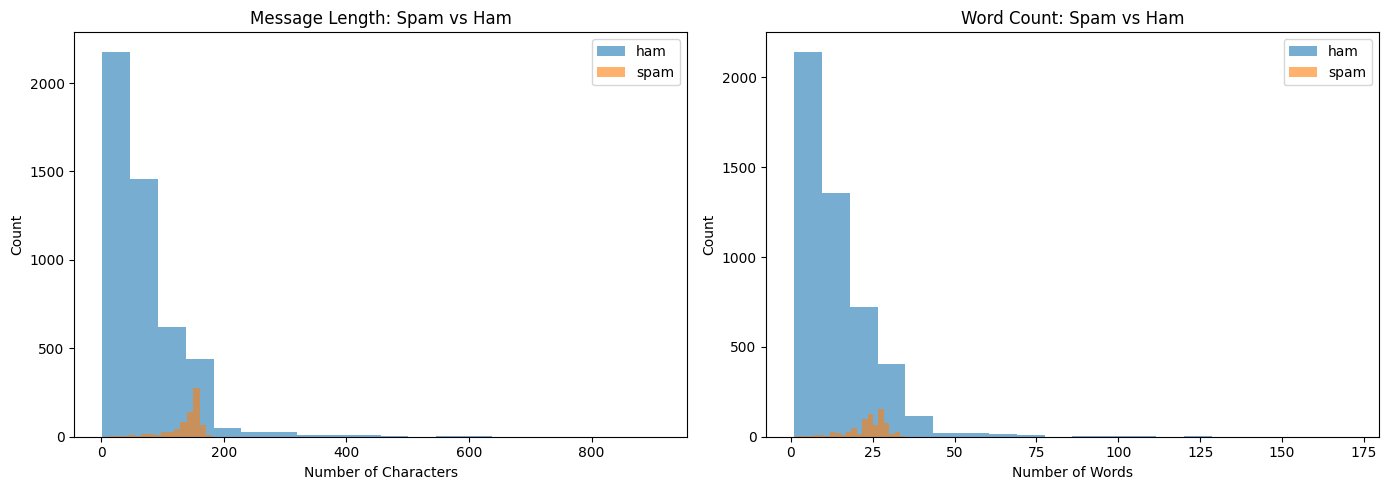

In [ ]:
# Explore the Data
df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print("Average stats by label:")
print(df.groupby('label')[['message_length', 'word_count']].mean().round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, group in df.groupby('label'):
    axes[0].hist(group['message_length'], alpha=0.6, label=label, bins=20)
axes[0].set_title('Message Length: Spam vs Ham')
axes[0].set_xlabel('Number of Characters')
axes[0].set_ylabel('Count')
axes[0].legend()

for label, group in df.groupby('label'):
    axes[1].hist(group['word_count'], alpha=0.6, label=label, bins=20)
axes[1].set_title('Word Count: Spam vs Ham')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150)
plt.show()

In [ ]:
#Preprocessing
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|bit\.ly\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    tokens = [word for word in tokens if len(word) > 1]
    return ' '.join(tokens)

df['clean_message'] = df['message'].apply(preprocess_text)

print("BEFORE and AFTER preprocessing:\n")
for i in range(5):
    print(f"Original : {df['message'][i]}")
    print(f"Cleaned  : {df['clean_message'][i]}")
    print("-" * 60)

BEFORE and AFTER preprocessing:

Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned  : go jurong point crazy available bugis great world la buffet cine got amore wat
------------------------------------------------------------
Original : Ok lar... Joking wif u oni...
Cleaned  : ok lar joking wif oni
------------------------------------------------------------
Original : Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
Cleaned  : free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply overs
------------------------------------------------------------
Original : U dun say so early hor... U c already then say...
Cleaned  : dun say early hor already say
------------------------------------------------------------
Original : Nah I don't think he goes to usf, he 

In [ ]:
#TF-IDF Vectorization
X = df['clean_message']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {len(X_train)} messages")
print(f"Test set    : {len(X_test)} messages")

vectorizer = TfidfVectorizer(max_features=500, ngram_range=(1, 2))

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

print(f"\nVocabulary size : {len(vectorizer.vocabulary_)} tokens")
print(f"Training matrix : {X_train_vec.shape}")

Training set: 4457 messages
Test set    : 1115 messages

Vocabulary size : 500 tokens
Training matrix : (4457, 500)


In [ ]:
#Train the Model
model = MultinomialNB(alpha=1.0)
model.fit(X_train_vec, y_train)

print("Model trained successfully!")
print(f"Classes: {model.classes_}")

spam_idx = list(model.classes_).index('spam')
ham_idx  = list(model.classes_).index('ham')

spam_score   = model.feature_log_prob_[spam_idx] - model.feature_log_prob_[ham_idx]
feature_names = vectorizer.get_feature_names_out()
top_spam_idx  = spam_score.argsort()[-15:][::-1]

print("\nTop 15 words most associated with SPAM:")
print("-" * 35)
for idx in top_spam_idx:
    print(f"  '{feature_names[idx]}'  (score: {spam_score[idx]:.2f})")

Model trained successfully!
Classes: ['ham' 'spam']

Top 15 words most associated with SPAM:
-----------------------------------
  'claim'  (score: 4.65)
  'prize'  (score: 4.39)
  'guaranteed'  (score: 3.88)
  'tone'  (score: 3.87)
  'ppm'  (score: 3.82)
  'nokia'  (score: 3.72)
  'urgent'  (score: 3.70)
  'awarded'  (score: 3.67)
  'pobox'  (score: 3.63)
  'txt'  (score: 3.62)
  'ringtone'  (score: 3.55)
  'tcs'  (score: 3.55)
  'award'  (score: 3.53)
  'collection'  (score: 3.51)
  'mob'  (score: 3.45)


Accuracy: 97.0%
(1082 out of 1115 correct)

Classification Report:
-------------------------------------------------------
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.98       966
        Spam       0.98      0.79      0.88       149

    accuracy                           0.97      1115
   macro avg       0.98      0.89      0.93      1115
weighted avg       0.97      0.97      0.97      1115



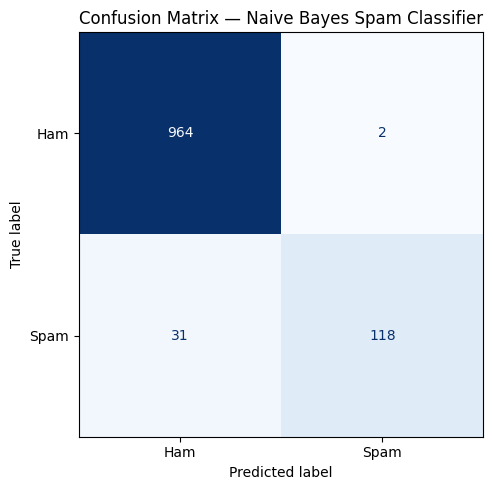


True Negatives  (TN): 964  → Ham correctly identified as Ham
False Positives (FP): 2  → Ham wrongly flagged as Spam
False Negatives (FN): 31  → Spam that slipped through
True Positives  (TP): 118  → Spam correctly caught


In [ ]:
#Evaluate the Model
y_pred = model.predict(X_test_vec)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.1f}%")
print(f"({int(accuracy * len(y_test))} out of {len(y_test)} correct)\n")

print("Classification Report:")
print("-" * 55)
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Naive Bayes Spam Classifier')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (TN): {tn}  → Ham correctly identified as Ham")
print(f"False Positives (FP): {fp}  → Ham wrongly flagged as Spam")
print(f"False Negatives (FN): {fn}  → Spam that slipped through")
print(f"True Positives  (TP): {tp}  → Spam correctly caught")

In [ ]:
#Test on New Messages
def predict_spam(messages):
    cleaned    = [preprocess_text(msg) for msg in messages]
    vectorized = vectorizer.transform(cleaned)
    predictions  = model.predict(vectorized)
    probabilities = model.predict_proba(vectorized)

    print("=" * 70)
    print(f"{'Message':<45} {'Result':<8} {'Confidence'}")
    print("=" * 70)
    for msg, pred, prob in zip(messages, predictions, probabilities):
        confidence = prob[list(model.classes_).index('spam')] * 100
        label = "SPAM" if pred == 'spam' else "HAM"
        flag  = "⚠" if pred == 'spam' else "✓"
        short = msg[:42] + "..." if len(msg) > 45 else msg
        print(f"{flag} {short:<45} {label:<8} {confidence:.1f}%")
    print("=" * 70)


test_messages = [
    "You have WON a FREE M-Pesa reward of KES 5000! Call 0712 now to claim!",
    "URGENT: Your Safaricom account will be deactivated. Verify at this link.",
    "Congratulations! You are our lucky customer. Reply CLAIM to get your prize.",
    "Hi, can you bring the textbook to class tomorrow morning?",
    "The group assignment is due on Monday. Have you done your part?",
    "Are you in Thika? Let us grab lunch after the afternoon lecture.",
    "Call me when you are free, we need to discuss the project urgently.",
    "Your account balance is low. Please top up to continue using services."
]

predict_spam(test_messages)

Message                                       Result   Confidence
⚠ You have WON a FREE M-Pesa reward of KES 5... SPAM     98.2%
⚠ URGENT: Your Safaricom account will be dea... SPAM     84.0%
⚠ Congratulations! You are our lucky custome... SPAM     98.8%
✓ Hi, can you bring the textbook to class to... HAM      0.8%
✓ The group assignment is due on Monday. Hav... HAM      14.4%
✓ Are you in Thika? Let us grab lunch after ... HAM      1.6%
✓ Call me when you are free, we need to disc... HAM      31.9%
⚠ Your account balance is low. Please top up... SPAM     67.7%


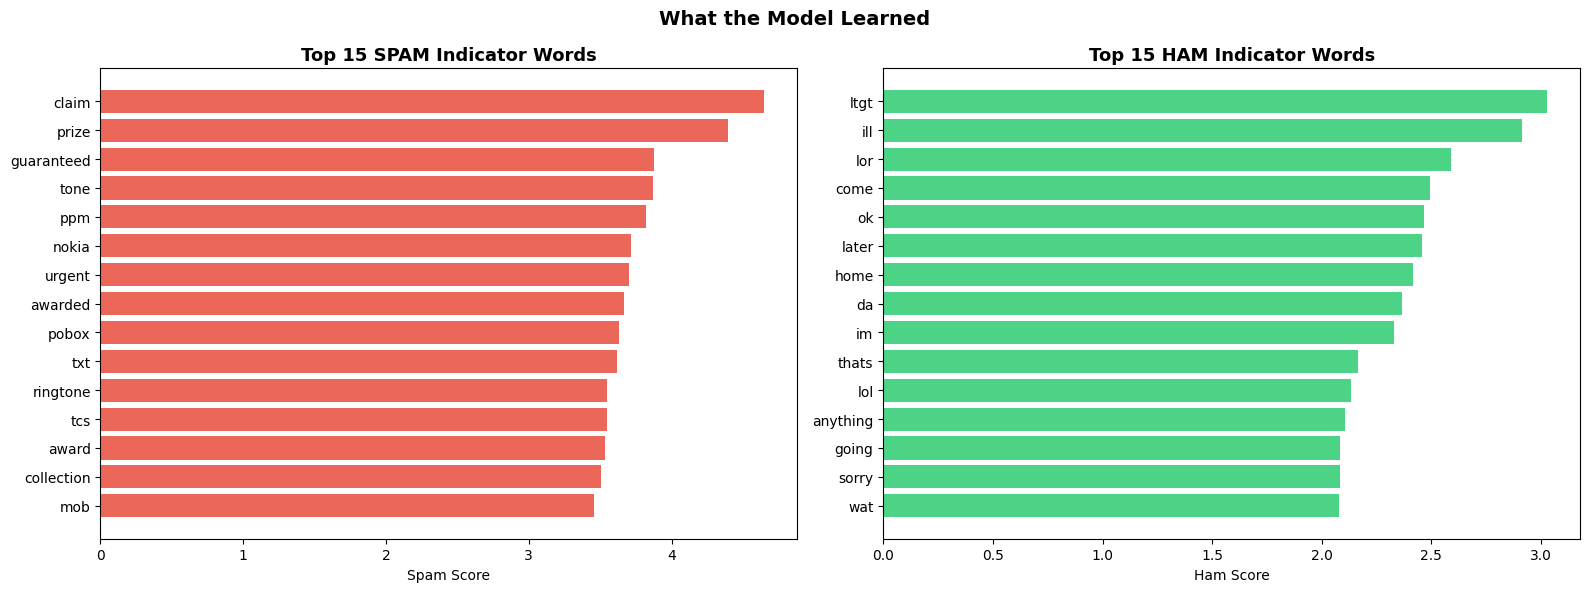

In [ ]:
#Feature Importance Chart
spam_class_idx = list(model.classes_).index('spam')
ham_class_idx  = list(model.classes_).index('ham')

log_prob_diff  = (model.feature_log_prob_[spam_class_idx] -
                  model.feature_log_prob_[ham_class_idx])

feature_names_arr = vectorizer.get_feature_names_out()
top_n = 15

top_spam_idx = log_prob_diff.argsort()[-top_n:][::-1]
top_ham_idx  = log_prob_diff.argsort()[:top_n]

spam_words  = [feature_names_arr[i] for i in top_spam_idx]
spam_scores = [log_prob_diff[i] for i in top_spam_idx]
ham_words   = [feature_names_arr[i] for i in top_ham_idx]
ham_scores  = [abs(log_prob_diff[i]) for i in top_ham_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(spam_words[::-1], spam_scores[::-1], color='#e74c3c', alpha=0.85)
axes[0].set_title('Top 15 SPAM Indicator Words', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Spam Score')

axes[1].barh(ham_words[::-1], ham_scores[::-1], color='#2ecc71', alpha=0.85)
axes[1].set_title('Top 15 HAM Indicator Words', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Ham Score')

plt.suptitle('What the Model Learned', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

In [ ]:
#Save the Model
import pickle

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('spam_classifier_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✓ Model saved: spam_classifier_model.pkl")
print("✓ Vectorizer saved: tfidf_vectorizer.pkl")
print("\nTo reload later:")
print("""
import pickle
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
with open('spam_classifier_model.pkl', 'rb') as f:
    model = pickle.load(f)
""")

✓ Model saved: spam_classifier_model.pkl
✓ Vectorizer saved: tfidf_vectorizer.pkl

To reload later:

import pickle
with open('tfidf_vectorizer.pkl', 'rb') as f:
    vectorizer = pickle.load(f)
with open('spam_classifier_model.pkl', 'rb') as f:
    model = pickle.load(f)

